# Gradient Descent Algorithm

## Example 1

Suppose we want to find the minimum of the function $$ f(x,y) = (x-47)^2 + (y - 0.1)^4 + 2. $$

In [116]:
#------------------------
# Import packages
#------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Change the plotting style
plt.style.use('seaborn-whitegrid')

# Uncomment to make pictures interactive
# %matplotlib notebook
%matplotlib inline

In [117]:
#------------------------
# Create functions
#------------------------

# Create the cost function
def costFunction(x,y):
    f = (x-47)**2 + (y - 0.1)**4 + 2
    return f

# Create the gradient vector
def gradf(x,y):
    gradient = np.array([2*(x - 47), 4*(y - 0.1)**3])
    return gradient

In [118]:
#------------------------
# Create variables
#------------------------

# Starting point
x0 = 80
y0 = 5

# Step size to move along gradient
gamma = 0.02
# Make vector for calculations later
gammaVec = gamma*np.ones(2)

# Starting point X0=(x0,y0) where X=(x,y)
X0 = np.array([x0,y0])

# initial diff
diff = 100
# initialize num of steps to take
totalNumSteps = 0
# create a max number of steps to take
maxSteps = 1000
# how close we want to be to function
tolerance = 0.001

# initialize x value to starting point
currentX = X0

#initialize value of objective function to f(X0)
currentCostFunValues = costFunction(X0[0], X0[1])

#------------------------
# Initialize lists
#------------------------

# creates list of all (x,y) pairs
xyValuesList = [currentX]
# creates list of all cost function values
costFunValuesList = [currentCostFunValues]

#------------------------
# Gradient descent calcs
#------------------------

while((totalNumSteps < maxSteps)&(diff > tolerance)):
    
    # Calculate new (x,y) values
    newX = currentX - gammaVec*gradf(currentX[0], currentX[1])
    # Calculate new function values with new (x,y) values
    newCostFunValues = costFunction(newX[0],newX[1])
    # Calculate the difference between current and new function values
    diff = abs(newCostFunValues-currentCostFunValues)
    
    # Add 1 to counter for total number of steps
    totalNumSteps += 1
    
    # Add to list of (x,y) values
    xyValuesList.append(newX)
    # Add to list of cost function values
    costFunValuesList.append(newCostFunValues)
    
    # Reassign current (x,y) to new (x,y)
    currentX = newX
    # Reassign current cost function values to new cost function values
    currentCostFunValues = newCostFunValues

In [147]:
#------------------------
# Format data for plot
#------------------------

# Data from above
df = pd.DataFrame(xyValuesList, columns = ['x', 'y'])

# Function values of f (to compare)
epsilon = 2
x = np.linspace(min(df['x'])-epsilon, max(df['x']+epsilon), 30)
y = np.linspace(min(df['y'])-epsilon, max(df['y']+epsilon), 30)

# Makes grid for plotting
X, Y = np.meshgrid(x, y)
# Cost function output for points on grid
Z = costFunction(X, Y)

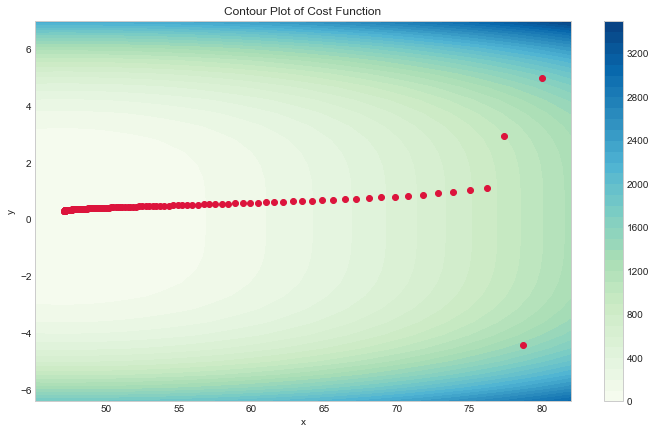

In [175]:
#------------------------
# Plot
#------------------------

# Make figure size
plt.figure(figsize=(12,7))

# Create contour plot
plt.contourf(X, Y, Z, 40, cmap='GnBu')
# Create colorbar for height
plt.colorbar()

# Plot our xyValues
plt.plot(df['x'], df['y'], 'o', color = 'crimson')

# Label axes and make title
plt.xlabel('x')
plt.ylabel('y')
plt.title('Contour Plot of Cost Function')

# Show plot
plt.show()

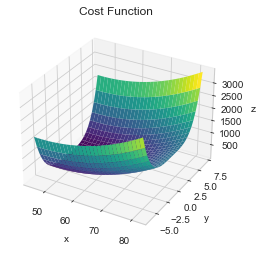

In [155]:
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, rstride=1, cstride=1,
                cmap='viridis', edgecolor='none')
ax.set_title('Cost Function');
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z');

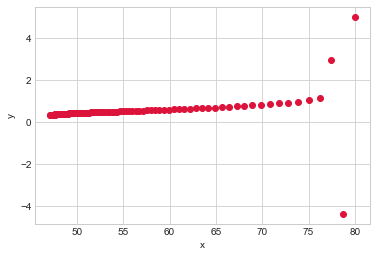

In [121]:
# Create the plot
plt.plot(df['x'], df['y'], 'o', color = 'crimson')
plt.xlabel('x')
plt.ylabel('y')
 
# Show the plot
plt.show()